Environment and Notebook Setup

In [ ]:
# No longer needed - data loads from GitHub
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# Install packages
!pip install pyampute
!pip install imbalanced-learn

In [2]:
# Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# Preprocessing Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE



print("Libraries successfully imported")

Libraries successfully imported


In [3]:
# Accessibility - to be applied to all plots
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colorblind safe palette
# Use Wong Color Blind Pallet Hex Codes
sns.set_palette("colorblind")

print("Libraries loaded and styling applied successfully")

Libraries loaded and styling applied successfully


In [4]:
# Load saved EDA dataset from GitHub

base_url = 'https://raw.githubusercontent.com/mnooney/CVD_Capstone/main/data/'
UCI = pd.read_csv(f'{base_url}capstone_cvd_eda.csv')
print("Dataset loaded:", UCI.shape)

Dataset loaded: (303, 14)


## Written by Katherine S. Geist, PhD
## Merrimack College, Massachusetts
## Please do not distribute without attribution
## https://github.com/ksgeist

In [5]:
import sys
## Check if packages are loaded; if not, import them
if 'numpy' not in sys.modules:
    import numpy as np
if 'pandas' not in sys.modules:
    import pandas as pd
def calcSplitRatio(df, p=None):
    """
    Calculate the ideal split ratio for training and testing sets.
    Parameters:
    p (int): The number of parameters (optional). If not provided, defaults to
    the number of columns minus 1 (assuming the last column is the target).
    df (DataFrame): The DataFrame that will be used for analysis.
    Returns:
    float: The training set proportion.
    """
    ## Set p to the number of predictors if not provided
    if p is None:
        p = df.shape[1] - 1 ## The number of features (predictors),
        ## assuming last column is target
    ## Calculate ideal number for testing set
    test_N = (1 / np.sqrt(p)) * len(df)
    ## Calculate testing proportion
    test_prop = round(test_N / len(df), 2)
    ## Calculate training proportion
    train_prop = 1 - test_prop
    ## Print the results
    print(f"The ideal split ratio is {train_prop}:{test_prop} training:testing")
    ## Return the size of the training set proportion
    return train_prop

In [ ]:
# Calculate ideal train/test split ratio
train_proportion = calcSplitRatio(UCI)

The ideal split ratio is 0.72:0.28 training:testing


Removal of Missing Rows

Upon going further downstream is pre-processing, row removal was done after splitting and found to severly impact test set. This section was added to correct for missingness removal in the original dataset. Previous work is left in place to show work and steps done.

In [6]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(UCI[['ca', 'thal']].isnull().sum())

# Drop rows with missing values in ca and thal
UCI_clean = UCI.dropna(subset=['ca', 'thal'])

# Confirm removal
print(f"\nRecords before cleaning: {len(UCI)}")
print(f"Records after cleaning: {len(UCI_clean)}")
print(f"Records removed: {len(UCI) - len(UCI_clean)}")

Missing values before cleaning:
ca      4
thal    2
dtype: int64

Records before cleaning: 303
Records after cleaning: 297
Records removed: 6


Train - Test Split

In [7]:
# Separate features and target
X = UCI_clean.drop(columns=['target'])
y = UCI_clean['target']

# Perform train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.28, # split from previous ratio test
    random_state = 42, # reproducibility
    stratify = y # maintain class ratio in both sets
)

# Confirm split sizes
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

# Save dimensions
original_train = len(X_train)
original_test = len(X_test)
original_total = original_train + original_test
print(f"Original training size: {original_train}")
print(f"Original test size: {original_test}")
print(f"Original total size: {original_total}")
#


Training set size: (213, 13)
Test set size: (84, 13)

Training target distribution:
target
0    0.54
1    0.46
Name: proportion, dtype: float64

Test target distribution:
target
0    0.536
1    0.464
Name: proportion, dtype: float64
Original training size: 213
Original test size: 84
Original total size: 297


Variable Encoding and Check

In [8]:
# Variable Encoding

# Columns to encode
nominal_cols = ['restecg', 'thal', 'cp']

# Encode training set
X_train_encoded = pd.get_dummies(X_train, columns = nominal_cols, drop_first=True)

# Encode test set
X_test_encoded = pd.get_dummies(X_test, columns = nominal_cols, drop_first=True)

# Align columns - ensure both sets have identical columns
X_train_encoded, X_test_encoded = X_train_encoded.align( # ensure both df have same columns in order, fill with 0 if not, avoid crash
    X_test_encoded, join='left', axis=1, fill_value=0)

print("Training set shape after encoding:", X_train_encoded.shape)
print("Test set shape after encoding:", X_test_encoded.shape)
print("\nNew columns added:")
print([col for col in X_train_encoded.columns if col not in X_train.columns]) # print the columns not listed in original X_train

Training set shape after encoding: (213, 17)
Test set shape after encoding: (84, 17)

New columns added:
['restecg_1', 'restecg_2', 'thal_6.0', 'thal_7.0', 'cp_2', 'cp_3', 'cp_4']


Assess for Missingness

In [9]:
# Source - https://stackoverflow.com/a/72143578
# Posted by Akis Hadjimpalasis, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-11, License - CC BY-SA 4.0

# rpy2 libraries
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects import globalenv


In [10]:
# Source - https://stackoverflow.com/a/72143578
# Posted by Akis Hadjimpalasis, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-11, License - CC BY-SA 4.0

# Import R's base package
base = importr("base")

# Import R's utility packages
utils = importr("utils")

# Select mirror
utils.chooseCRANmirror(ind=1)

# For automatic translation of Pandas objects to R
pandas2ri.activate()

# Enable R magic
%load_ext rpy2.ipython

# Make your Pandas dataframe accessible to R
globalenv["r_df"] = UCI


In [11]:
# Source - https://stackoverflow.com/a/72143578
# Posted by Akis Hadjimpalasis, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-11, License - CC BY-SA 4.0

utils.install_packages("remotes")
%R remotes::install_github("njtierney/naniar")


(as ‘lib’ is unspecified)







	‘/tmp/RtmpDBokHj/downloaded_packages’



These packages have more recent versions available.
It is recommended to update all of them.
Which would you like to update?

 1: All                                   
 2: CRAN packages only                    
 3: None                                  
 4: rlang    (1.1.7   -> 1.2.0    ) [CRAN]
 5: cli      (3.6.5   -> 3.6.6    ) [CRAN]
 6: glue     (1.8.0   -> 1.8.1    ) [CRAN]
 7: Rcpp     (1.1.1   -> 1.1.1-1.1) [CRAN]
 8: cpp11    (0.5.3   -> 0.5.5    ) [CRAN]
 9: vctrs    (0.7.2   -> 0.7.3    ) [CRAN]
10: S7       (0.2.1   -> 0.2.2    ) [CRAN]
11: magrittr (2.0.4   -> 2.0.5    ) [CRAN]
12: bit64    (4.6.0-1 -> 4.8.0    ) [CRAN]
13: purrr    (1.2.1   -> 1.2.2    ) [CRAN]
14: dplyr    (1.2.0   -> 1.2.1    ) [CRAN]
15: ggplot2  (4.0.2   -> 4.0.3    ) [CRAN]

Enter one or more numbers, or an empty line to skip updates: 1
rlang     (1.1.7   -> 1.2.0    ) [CRAN]
cli       (3.6.5   -> 3.6.6    ) [CRAN]
glue      (1.8.0   -> 1.8.1    ) [CRAN]
Rcpp      (1.1.1   -> 1.1.1-1.1) [CRAN]
cpp11

Installing 18 packages: rlang, cli, glue, Rcpp, cpp11, vctrs, S7, magrittr, bit64, purrr, dplyr, plyr, gridExtra, ggplot2, UpSetR, viridis, visdat, norm
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/rlang_1.2.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/cli_3.6.6.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/glue_1.8.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/Rcpp_1.1.1-1.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/cpp11_0.5.5.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/vctrs_0.7.3.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/S7_0.2.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/magrittr_2.0.5.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/bit64_4.8.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/purrr_1.2.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/

In [12]:
# Source - https://stackoverflow.com/a/72143578
# Posted by Akis Hadjimpalasis, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-11, License - CC BY-SA 4.0

%R library(naniar)


array(['naniar', 'tools', 'stats', 'graphics', 'grDevices', 'utils',
       'datasets', 'methods', 'base'], dtype='<U9')

In [13]:
# Source - https://stackoverflow.com/a/72143578
# Posted by Akis Hadjimpalasis, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-11, License - CC BY-SA 4.0

# mcar_test on whole df
%R mcar_test(r_df)


,statistic,df,p.value,missing.patterns
1,17.336231,26.0,0.898574,3


In [14]:
# MCAR Interpretation

# Store p-value from Little's MCAR test result
mcar_p_value = 0.8986

print(f"Little's MCAR Test Results:")
print(f"p-value: {mcar_p_value}")
print()

if mcar_p_value > 0.05:
    print("Result: FAIL TO REJECT null hypothesis")
    print("Interpretation: Missing values appear to be Missing Completely At Random")
else:
    print("Result: REJECT null hypothesis")
    print("Interpretation: Missing values may NOT be MCAR.")

Little's MCAR Test Results:
p-value: 0.8986

Result: FAIL TO REJECT null hypothesis
Interpretation: Missing values appear to be Missing Completely At Random


The following code commented out due to change in dataset split, left for reference.

In [ ]:
# Drop Missing Rows

# Create missing masks for both train and test sets
# Using original unencoded sets where ca and thal still exist
#train_missing_mask = X_train[['ca', 'thal']].isnull().any(axis=1)
#test_missing_mask = X_test[['ca', 'thal']].isnull().any(axis=1)

# Drop from original sets
# X_train_clean = X_train[~train_missing_mask]
# X_test_clean = X_test[~test_missing_mask]

# Drop from encoded sets using same mask
# X_train_encoded_clean = X_train_encoded[~train_missing_mask]
# X_test_encoded_clean = X_test_encoded[~test_missing_mask]

# # Drop from target sets
# y_train_clean = y_train[~train_missing_mask]
# y_test_clean = y_test[~test_missing_mask]

# # Confirm new shapes
# print("After dropping missing rows:")
# print(f"X_train: {X_train_clean.shape}")
# print(f"X_test: {X_test_clean.shape}")
# print(f"X_train_encoded: {X_train_encoded_clean.shape}")
# print(f"X_test_encoded: {X_test_encoded_clean.shape}")
# print(f"y_train: {y_train_clean.shape}")
# print(f"y_test: {y_test_clean.shape}")
# print(f"\nTotal records remaining: {len(X_train_clean) + len(X_test_clean)}")

In [ ]:
# Missing Value Impact

# Current sizes after dropping missing rows
# current_train = len(X_train_clean)
# current_test = len(X_test_clean)
# current_total = current_train + current_test

# # Calculate losses
# train_lost = original_train - current_train
# test_lost = original_test - current_test
# total_lost = original_total - current_total

# # Calculate percentages
# pct_train_lost = (train_lost / original_train) * 100
# pct_test_lost = (test_lost / original_test) * 100
# pct_total_lost = (total_lost / original_total) * 100

# print("Missing Value Drop Summary")

# print(f"{'Set':<12} {'Original':>10} {'Current':>10} {'Lost':>8} {'% Lost':>8}")
# print(f"{'Training':<12} {original_train:>10} {current_train:>10} {train_lost:>8} {pct_train_lost:>7.1f}%")
# print(f"{'Test':<12} {original_test:>10} {current_test:>10} {test_lost:>8} {pct_test_lost:>7.1f}%")
# print(f"{'Total':<12} {original_total:>10} {current_total:>10} {total_lost:>8} {pct_total_lost:>7.1f}%")
# print(f"\nNote: {test_lost} of {total_lost} missing rows ({(test_lost/total_lost)*100:.0f}%)")
# print(f"fell in the test set")

At this point it is found that the test set is too affected by missingness drop. Values will be dropped from original set, and re-split and encoded.

Transformation

In [15]:
# Shapiro Wilkes on Continous Variables to Assess for Transformation Needs

continuous = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in continuous:
    stat, p_value = stats.shapiro(X_train_encoded[col])
    result = "NOT normal" if p_value < 0.05 else "Normal"
    print(f"{col}: statistic={stat:.4f}, p-value={p_value:.4f} → {result}")



age: statistic=0.9832, p-value=0.0124 → NOT normal
trestbps: statistic=0.9769, p-value=0.0014 → NOT normal
chol: statistic=0.9315, p-value=0.0000 → NOT normal
thalach: statistic=0.9770, p-value=0.0015 → NOT normal
oldpeak: statistic=0.8357, p-value=0.0000 → NOT normal


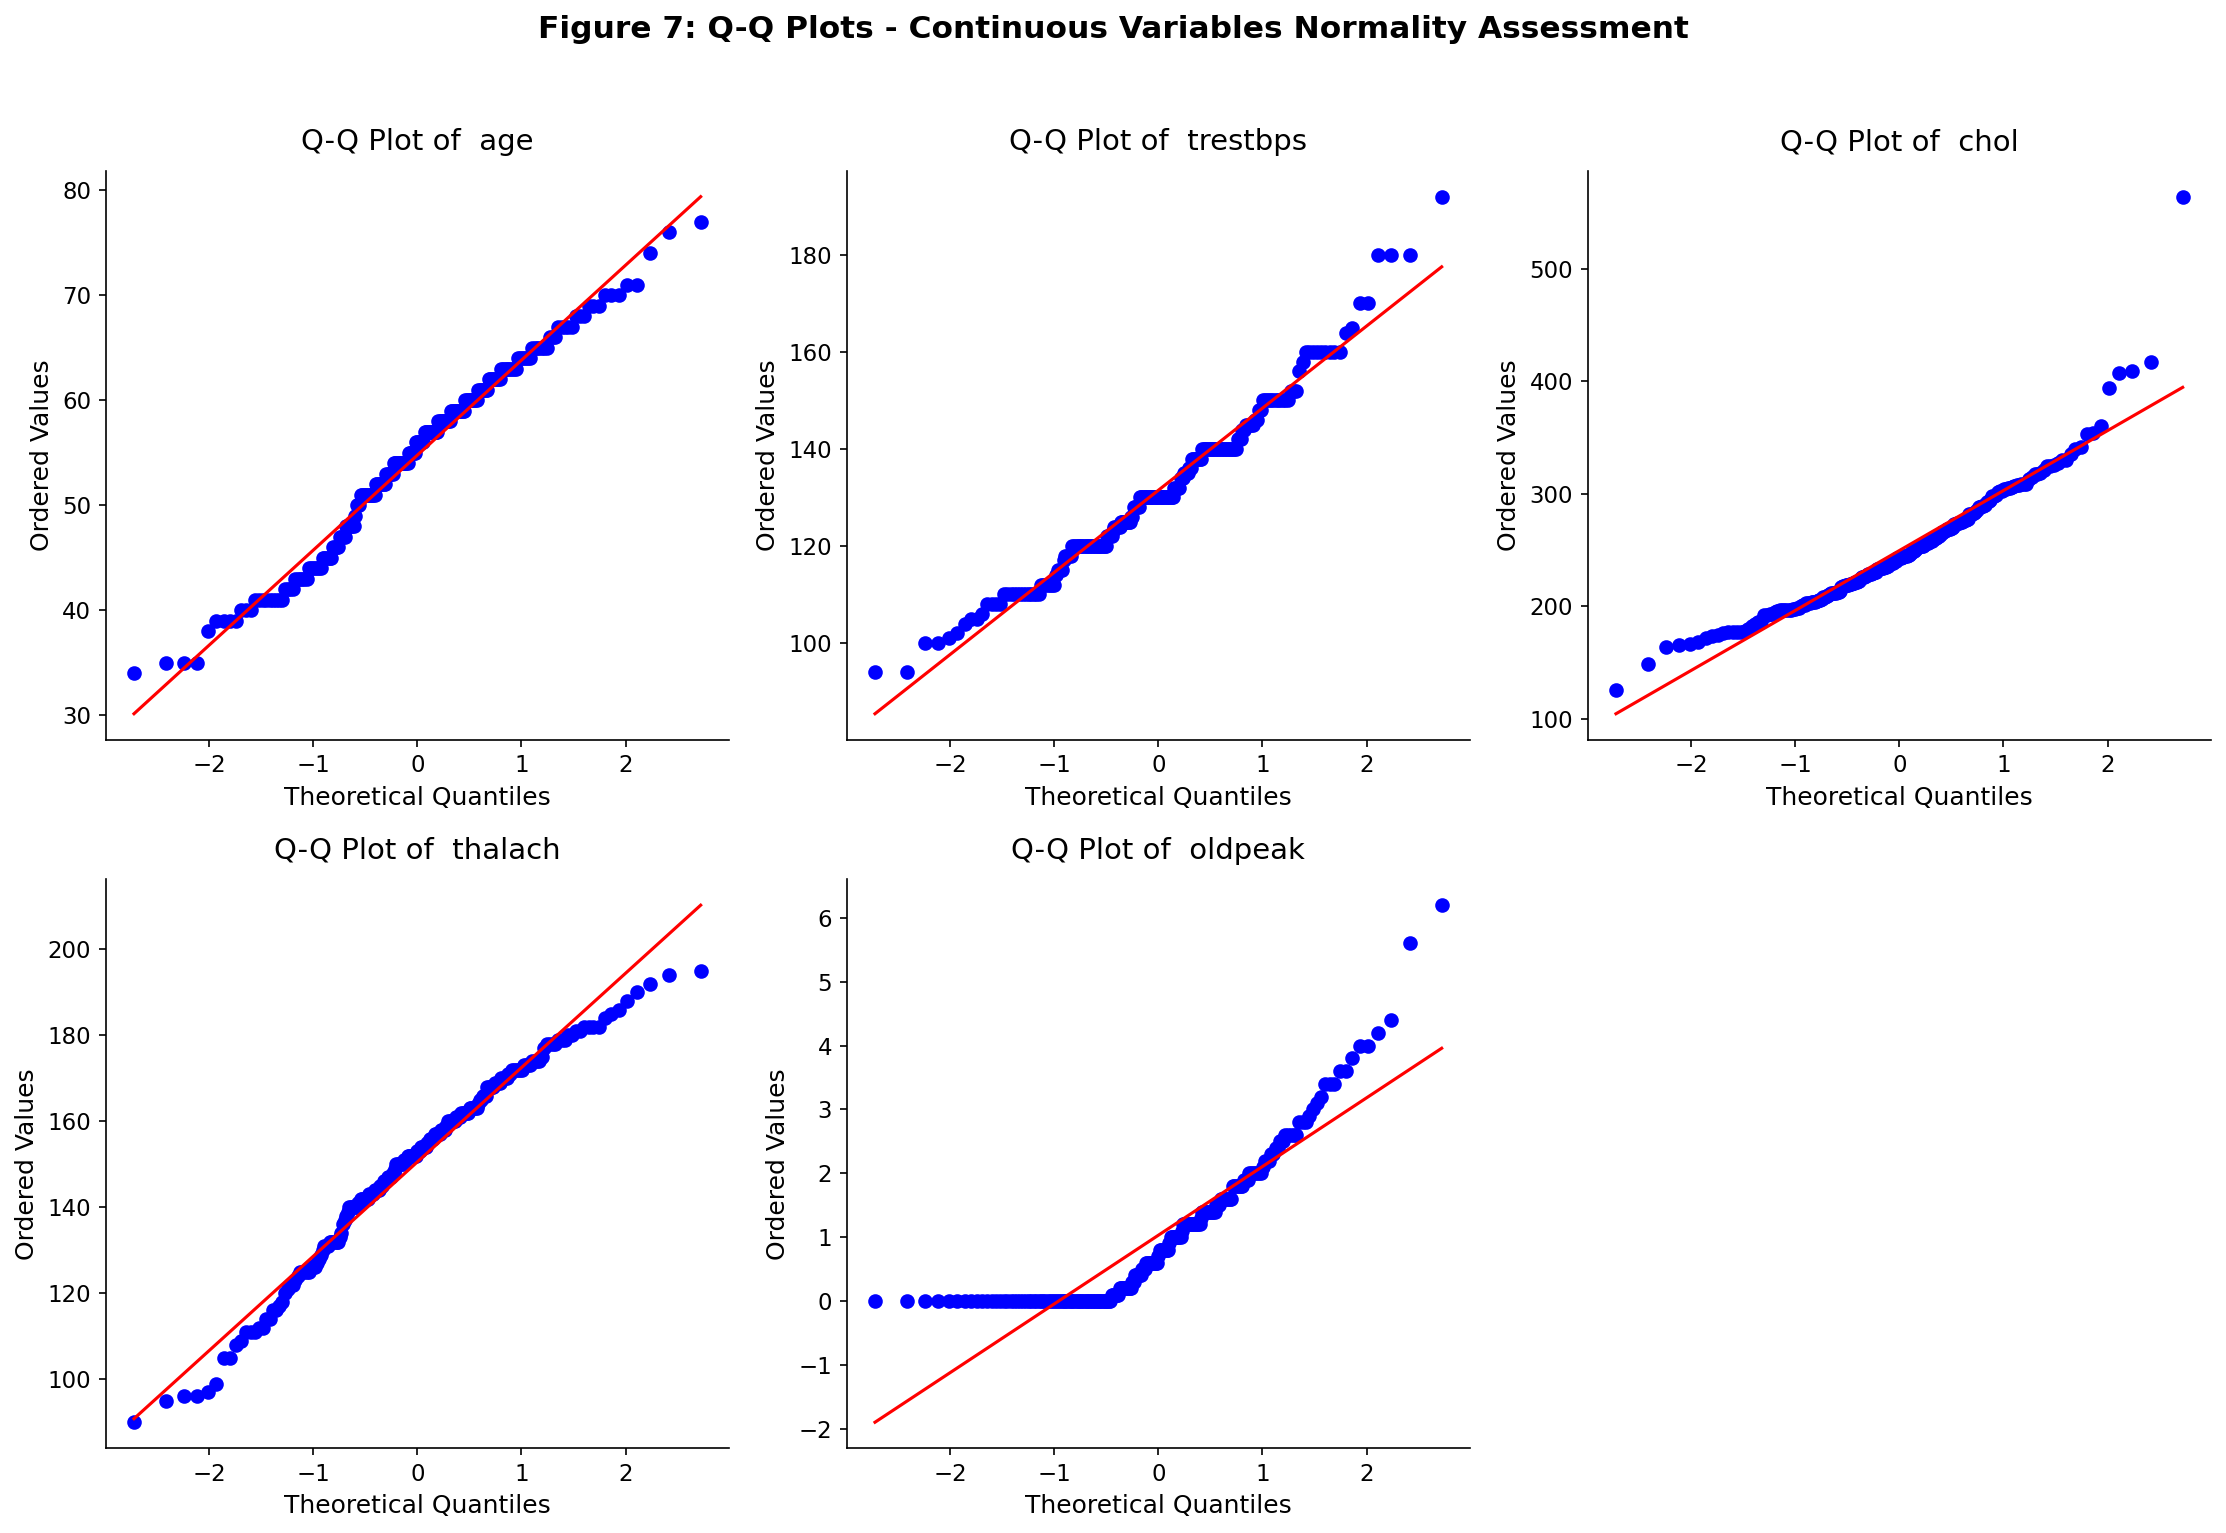

Figure 7 saved


In [16]:
# Q-Q Plot

fig, axes = plt.subplots(2, 3, figsize=(15, 10)) # grid of 6 plots, 2 rows, 3 columns
axes = axes.flatten() # simpler loop thorugh each plot

for i, col in enumerate(continuous):
    stats.probplot(X_train_encoded[col], dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot of  {col}',
                      fontsize=14, pad=10)
    axes[i].set_xlabel('Theoretical Quantiles', fontsize=12)
    axes[i].set_ylabel('Ordered Values', fontsize=12)


# Hide unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Figure 7: Q-Q Plots - Continuous Variables Normality Assessment',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure7_qq_plots.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 7 saved")


In [17]:
# Box - Cox Transformation

from scipy.stats import boxcox

# Apply to cholesterol
X_train_encoded['chol_boxcox'], lambda_chol = boxcox(X_train_encoded['chol'])
X_test_encoded['chol_boxcox'] = boxcox(X_test_encoded['chol'], lmbda = lambda_chol)

# Apply to oldpeak with shift
X_train_encoded['oldpeak_boxcox'], lambda_oldpeak = boxcox(X_train_encoded['oldpeak'] + 1)
X_test_encoded['oldpeak_boxcox'] = boxcox(X_test_encoded['oldpeak'] +1, lmbda = lambda_oldpeak)

# Print lambda values
print(f"Lambda for cholesterol: {lambda_chol:.4f}")
print(f"Lambda for oldpeak: {lambda_oldpeak:.4f}")

Lambda for cholesterol: -0.3594
Lambda for oldpeak: -0.5266


In [18]:
# Shapiro - Wilk Post Transformation

boxcox_transform = ['chol_boxcox', 'oldpeak_boxcox']

for col in boxcox_transform:
    stat, p_value = stats.shapiro(X_train_encoded[col])
    result = "NOT normal" if p_value < 0.05 else "Normal"
    print(f"{col}: statistic={stat:.4f}, p-value={p_value:.4f} → {result}")

chol_boxcox: statistic=0.9937, p-value=0.5050 → Normal
oldpeak_boxcox: statistic=0.8775, p-value=0.0000 → NOT normal


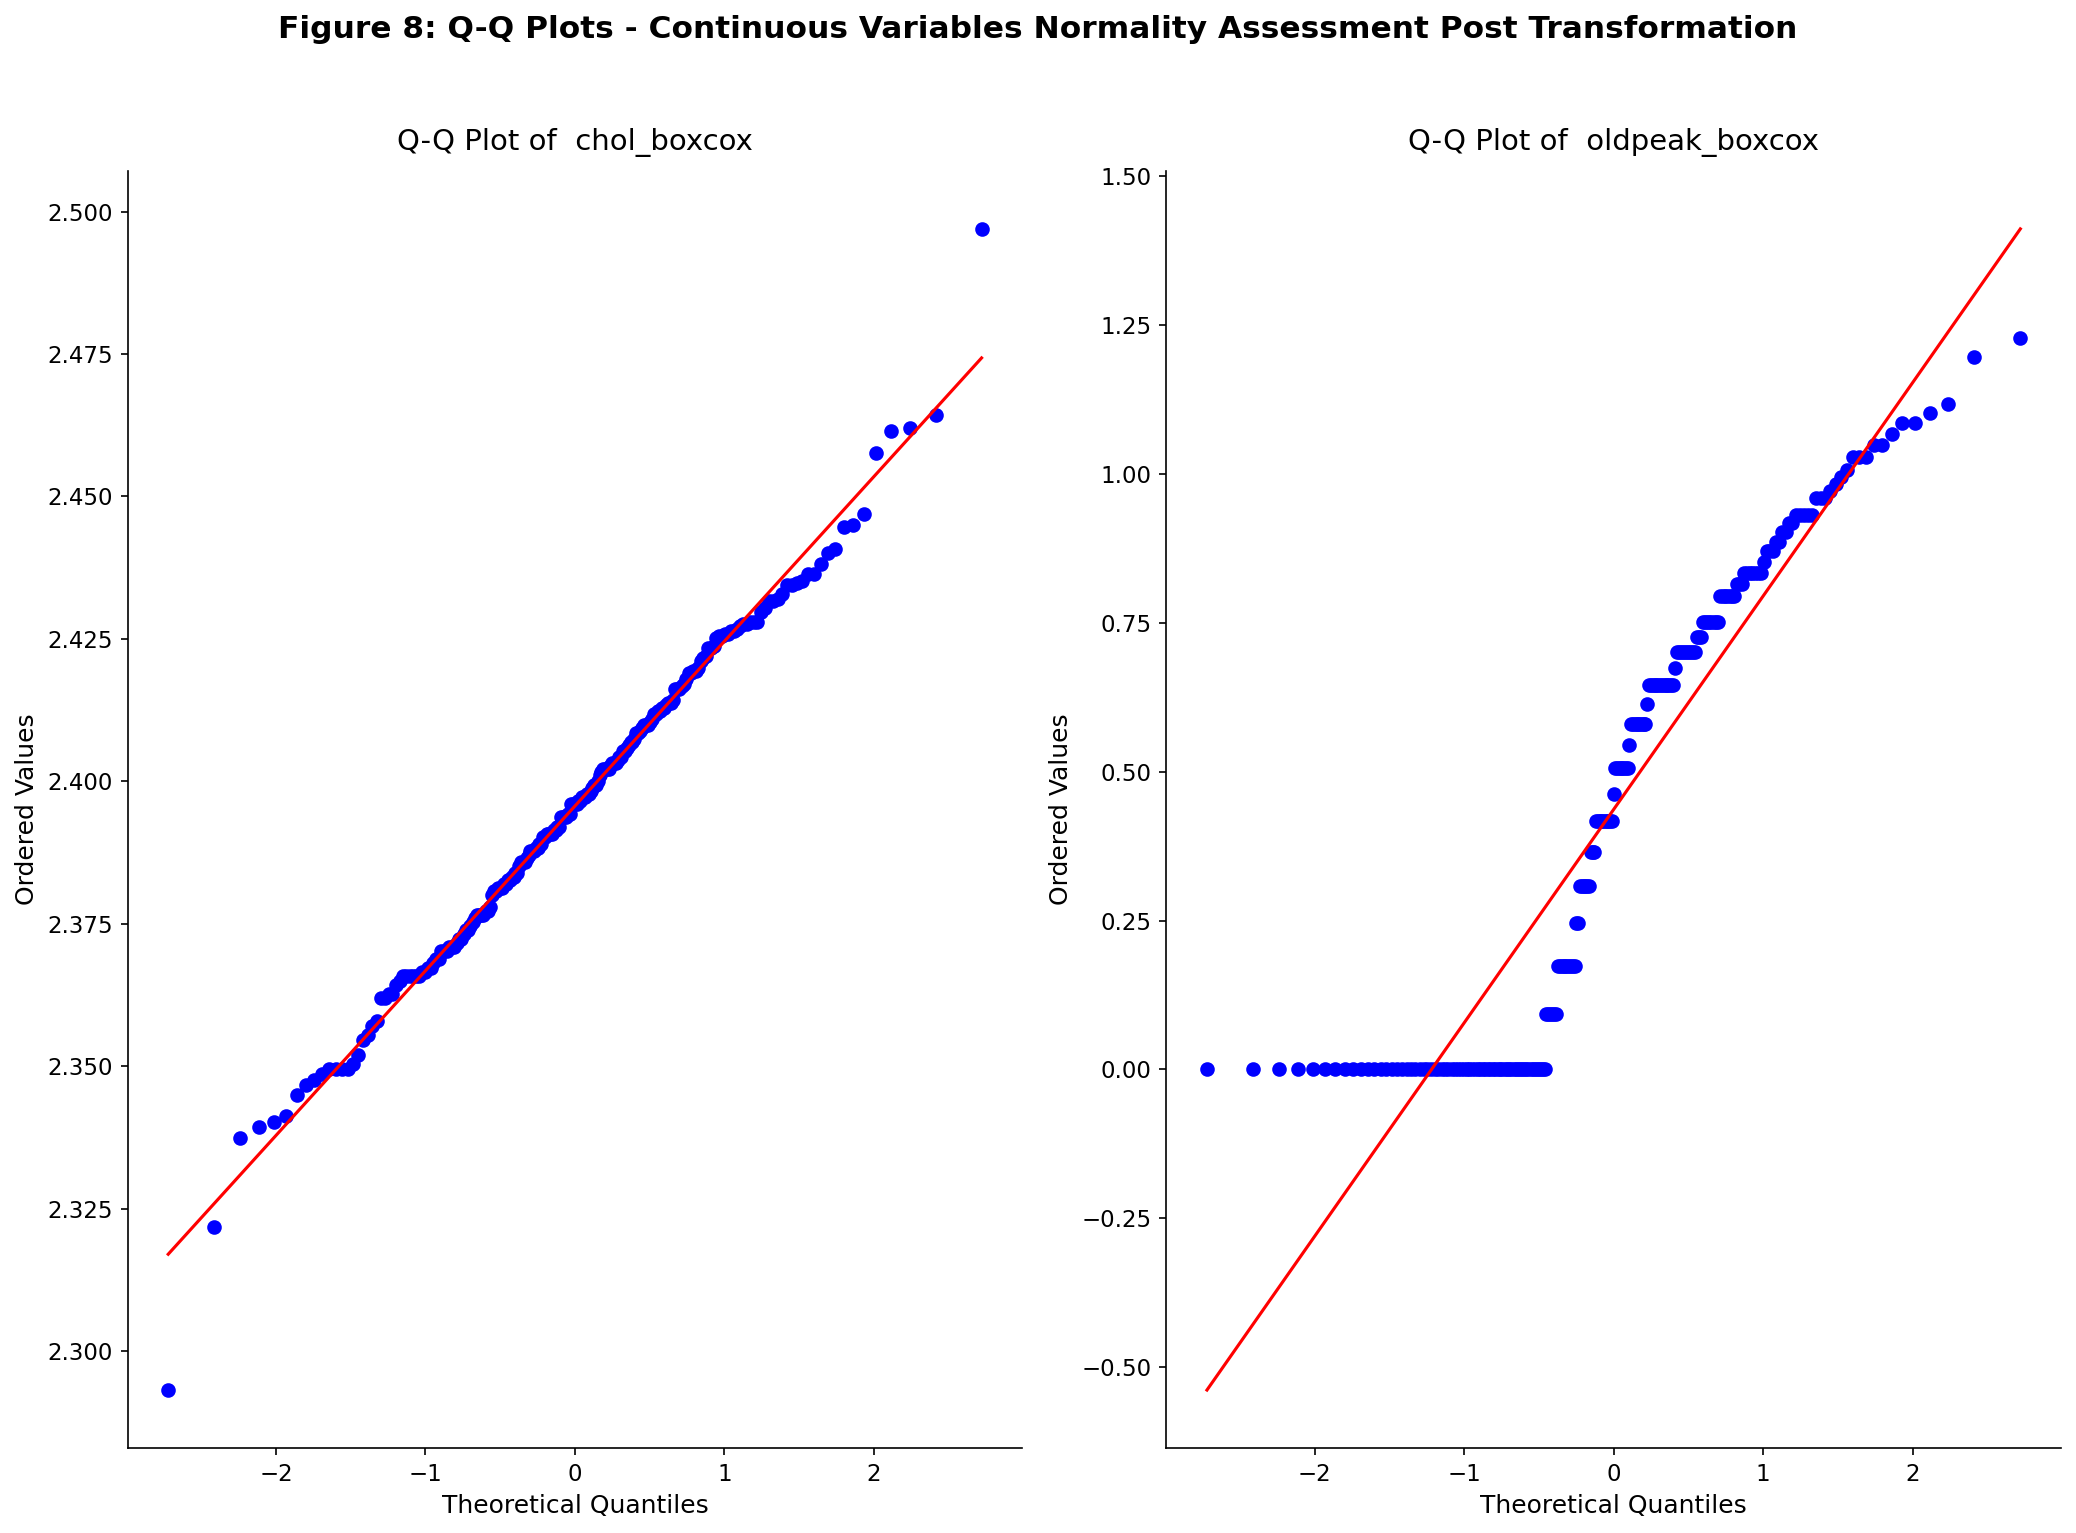

Figure 8 saved


In [19]:
# Q - Q Plots Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
axes = axes.flatten() # simpler loop thorugh each plot

# Create comparison variables
boxcox_transform = [ 'chol_boxcox','oldpeak_boxcox']

for i, col in enumerate(boxcox_transform):
    stats.probplot(X_train_encoded[col], dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot of  {col}',
                      fontsize=14, pad=10)
    axes[i].set_xlabel('Theoretical Quantiles', fontsize=12)
    axes[i].set_ylabel('Ordered Values', fontsize=12)



plt.suptitle('Figure 8: Q-Q Plots - Continuous Variables Normality Assessment Post Transformation',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure8_qq_plots.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 8 saved")

In [20]:
# Drop columns to prevent redundant features
# Pre Drop
print({X_train_encoded.shape})
print({X_test_encoded.shape})

# Drop oldpeak and chol from training and test sets after transformation

X_train_encoded = X_train_encoded.drop(columns=['chol', 'oldpeak'])
X_test_encoded = X_test_encoded.drop(columns=['chol', 'oldpeak'])

# Post drop
print({X_train_encoded.shape})
print({X_test_encoded.shape})

{(213, 19)}
{(84, 19)}
{(213, 17)}
{(84, 17)}


Feature Engineering

In [21]:
# ST_severity variable creation - combine oldpeak and slope into single ordinal feature
# need to use initial X_train and X_test to get unencoded and pre-transformed values

# Create function to apply condition definition to both training and test sets
def create_st_severity(oldpeak, slope):
    # Define conditions in order of priority
    conditions = [
        # Category 0 - Negative
        # No ST depression OR less than 1mm with flat/downsloping
        (oldpeak == 0) | ((oldpeak < 1) & (slope.isin([2, 3]))),

        # Category 1 - Equivocal
        # Any upsloping ST depression regardless of amount
        (oldpeak > 0) & (slope == 1),

        # Category 2 - Positive
        # 1-2mm depression with flat or downsloping
        (oldpeak >= 1) & (oldpeak < 2) & (slope.isin([2, 3])),

        # Category 3 - Strongly Positive
        # 2mm or more depression with flat or downsloping
        (oldpeak >= 2) & (slope.isin([2, 3]))
    ]

    # Corresponding values for each condition
    choices = [0, 1, 2, 3]

    # Go through each condition in order
    # Apply conditions default 0 if no matches
    return np.select(conditions, choices, default=0)

# Apply to training set using original unencoded values
X_train_encoded['st_severity'] = create_st_severity(
    X_train['oldpeak'],
    X_train['slope']
)

# Apply to test set using original unencoded values
X_test_encoded['st_severity'] = create_st_severity(
    X_test['oldpeak'],
    X_test['slope']
)

# Check distribution of new feature
print("st_severity distribution - Training set:")
print(X_train_encoded['st_severity'].value_counts().sort_index())
print("\nProportions:")
print(X_train_encoded['st_severity'].value_counts(
    normalize=True).sort_index().round(3))

print("\nst_severity distribution - Test set:")
print(X_test_encoded['st_severity'].value_counts().sort_index())
print("\nProportions:")
print(X_test_encoded['st_severity'].value_counts(
    normalize=True).sort_index().round(3))

st_severity distribution - Training set:
st_severity
0    90
1    46
2    38
3    39
Name: count, dtype: int64

Proportions:
st_severity
0    0.423
1    0.216
2    0.178
3    0.183
Name: proportion, dtype: float64

st_severity distribution - Test set:
st_severity
0    38
1    12
2    17
3    17
Name: count, dtype: int64

Proportions:
st_severity
0    0.452
1    0.143
2    0.202
3    0.202
Name: proportion, dtype: float64


In [22]:
# Drop columns to prevent redundant features
# Pre Drop
print({X_train_encoded.shape})
print({X_test_encoded.shape})

# Drop oldpeak_boxcox and slope from training and test sets after transformation

X_train_encoded = X_train_encoded.drop(columns=['slope', 'oldpeak_boxcox'])
X_test_encoded = X_test_encoded.drop(columns=['slope', 'oldpeak_boxcox'])

# Post drop
print({X_train_encoded.shape})
print({X_test_encoded.shape})


{(213, 18)}
{(84, 18)}
{(213, 16)}
{(84, 16)}


In [23]:
# Quick check on column names to verify correctness
print(X_train_encoded.columns.tolist())

['age', 'sex', 'trestbps', 'fbs', 'thalach', 'exang', 'ca', 'restecg_1', 'restecg_2', 'thal_6.0', 'thal_7.0', 'cp_2', 'cp_3', 'cp_4', 'chol_boxcox', 'st_severity']


In [24]:
# Validation of st_severity Against Target Variable

# create frequency table of variable relationship
crosstab = pd.crosstab(X_train_encoded['st_severity'], # rows
                        y_train, # columns
                        normalize='index') * 100 # create proportions

crosstab.columns = ['No CVD %', 'CVD Present %'] # rename columns
crosstab.index.name = 'ST Severity' # index name for readability
print("CVD Prevalence by ST Severity Category:")
print(crosstab.round(1))

CVD Prevalence by ST Severity Category:
             No CVD %  CVD Present %
ST Severity                         
0                68.9           31.1
1                71.7           28.3
2                39.5           60.5
3                12.8           87.2


Scaling Features

In [25]:
# Apply Scaling to Continous Variables

# Fit on training then apply to test
# Columns to scale
scale_cols = ['age', 'trestbps', 'chol_boxcox', 'thalach']

# Create scaler
scaler = StandardScaler()

# Fit and transform on training only
X_train_encoded[scale_cols] = scaler.fit_transform(X_train_encoded[scale_cols])

# Apply to test set, no re-fitting
X_test_encoded[scale_cols] = scaler.transform(X_test_encoded[scale_cols])

print("Training set scaled:")
print(X_train_encoded[scale_cols].describe().round(2))

Training set scaled:
          age  trestbps  chol_boxcox  thalach
count  213.00    213.00       213.00   213.00
mean     0.00     -0.00        -0.00     0.00
std      1.00      1.00         1.00     1.00
min     -2.30     -2.21        -3.57    -2.76
25%     -0.75     -0.68        -0.69    -0.53
50%      0.14     -0.09         0.01     0.11
75%      0.69      0.50         0.71     0.80
max      2.47      3.57         3.53     2.03


In [26]:
# Test Set Check After Scale Application

print("Test set scaled:")
print(X_test_encoded[scale_cols].describe().round(2))

Test set scaled:
         age  trestbps  chol_boxcox  thalach
count  84.00     84.00        84.00    84.00
mean   -0.08      0.05        -0.13    -0.15
std     1.01      1.16         0.96     1.15
min    -2.86     -1.86        -3.33    -3.63
25%    -0.78     -0.68        -0.67    -0.94
50%     0.14     -0.09        -0.04     0.11
75%     0.58      0.50         0.50     0.62
max     1.80      4.04         1.56     2.34


SMOTE Exploration For Class Imbalance

In [27]:
# Create a SMOTE Training Set
# SMOTE Exploration for mild class imbalance
# To be compared to non-SMOTE traing set later

from imblearn.over_sampling import SMOTE

# Check class distribution prior
print("Class distribution prior to SMOTE:")
print(y_train.value_counts())
print(f"Ratio: {y_train.value_counts(normalize=True).round(3).to_dict}")

# Create SMOTE object
smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_encoded, y_train)

# Check after
print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())
print(f"Ratio: {y_train_smote.value_counts(normalize=True).round(3).to_dict()}")
print(f"\nTraining set size before SMOTE: {len(X_train_encoded)}")
print(f"Training set size after SMOTE: {len(X_train_smote)}")

Class distribution prior to SMOTE:
target
0    115
1     98
Name: count, dtype: int64
Ratio: <bound method Series.to_dict of target
0    0.54
1    0.46
Name: proportion, dtype: float64>

Class distribution after SMOTE:
target
0    115
1    115
Name: count, dtype: int64
Ratio: {0: 0.5, 1: 0.5}

Training set size before SMOTE: 213
Training set size after SMOTE: 230


PCA - Dimensionality Reduction Method - Unsupervised Learning

In [28]:
# Select only continuous columns

pca_cols = ['age', 'trestbps', 'thalach', 'chol_boxcox']

# Fit on training set only
pca = PCA()
pca.fit(X_train_encoded[pca_cols])

# Explained variance
explained_variance = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Print results
print("Explained Variance:")
print(explained_variance)
print("\nCumulative Explained Variance:")
print(cumulative_variance)


Explained Variance:
[0.38600538 0.27664947 0.20439854 0.1329466 ]

Cumulative Explained Variance:
[0.38600538 0.66265486 0.8670534  1.        ]


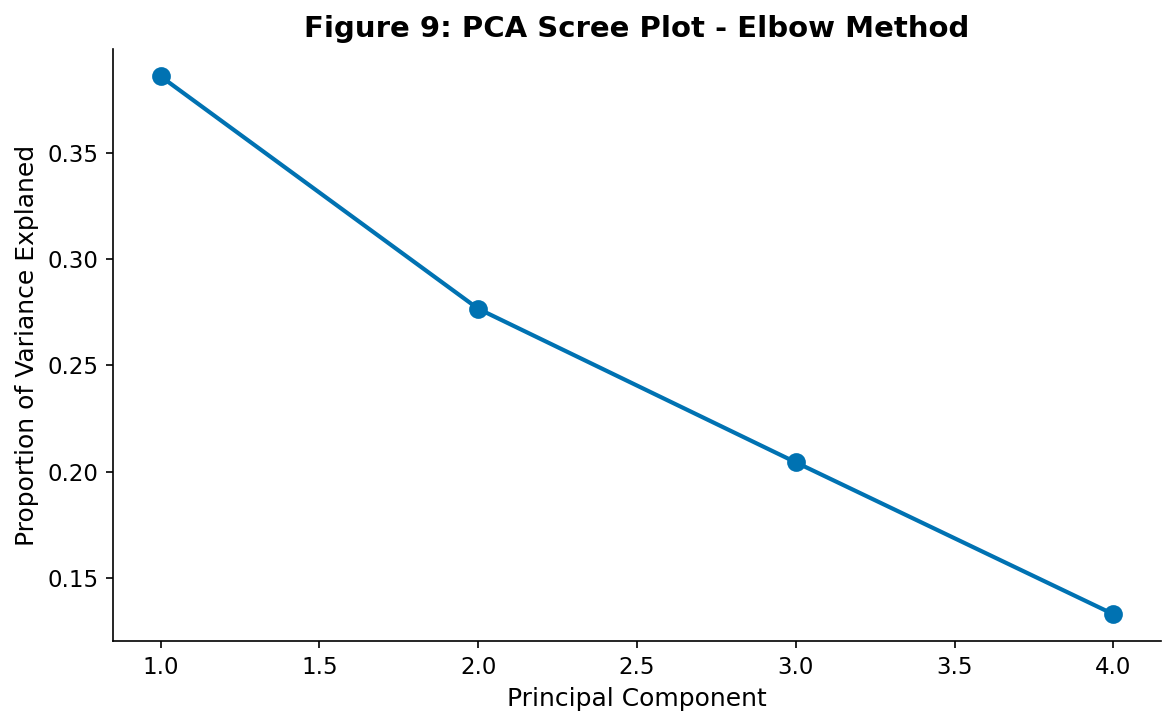

Figure 9 saved


In [29]:
# PCA Scree Plot

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(range(1, len(explained_variance) + 1),
        explained_variance,
        marker='o',
        color='#0072B2',
        linewidth=2, markersize=8)


ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Proportion of Variance Explaned', fontsize=12)
ax.set_title('Figure 9: PCA Scree Plot - Elbow Method', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('figure9_pca_scree.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 9 saved")

In [30]:
# VIF Check To Confirm MultiCollinearity Resolved

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Make a copy to avoid modifying the original DataFrame directly
# and convert boolean columns to integers for VIF calculation
X_train_encoded_numeric = X_train_encoded.copy()
for col in X_train_encoded_numeric.columns:
    if X_train_encoded_numeric[col].dtype == 'bool':
        X_train_encoded_numeric[col] = X_train_encoded_numeric[col].astype(int)

# Calculate VIF for each feature in training set
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_encoded_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(
    X_train_encoded_numeric.values, i)
    for i in range(X_train_encoded_numeric.shape[1])]

print("Variance Inflation Factor Results:")
print(vif_data.sort_values('VIF', ascending=False).round(2))
print("\nVIF > 10 indicates severe multicollinearity")
print("VIF > 5 indicates moderate multicollinearity")

Variance Inflation Factor Results:
        Feature   VIF
1           sex  4.01
13         cp_4  3.57
15  st_severity  2.65
10     thal_7.0  2.58
8     restecg_2  2.16
5         exang  2.08
6            ca  2.06
12         cp_3  1.69
4       thalach  1.60
0           age  1.50
11         cp_2  1.43
9      thal_6.0  1.36
3           fbs  1.34
2      trestbps  1.19
14  chol_boxcox  1.17
7     restecg_1  1.14

VIF > 10 indicates severe multicollinearity
VIF > 5 indicates moderate multicollinearity


Save Datasets to Drive

In [31]:
# Datasets saved to GitHub /data folder
# Available at: https://raw.githubusercontent.com/mnooney/CVD_Capstone/main/data/

# Original clean sets saved for reference
# X_train_encoded.to_csv('/content/drive/MyDrive/X_train_encoded.csv', index=False)
# X_test_encoded.to_csv('/content/drive/MyDrive/X_test_encoded.csv', index=False)
# y_train.to_csv('/content/drive/MyDrive/y_train.csv', index=False)
# y_test.to_csv('/content/drive/MyDrive/y_test.csv', index=False)

# SMOTE sets
# X_train_smote.to_csv('/content/drive/MyDrive/X_train_smote.csv', index=False)
# y_train_smote.to_csv('/content/drive/MyDrive/y_train_smote.csv', index=False)

print("All datasets available in GitHub /data folder")
print(f"X_train_encoded: {X_train_encoded.shape}")
print(f"X_test_encoded: {X_test_encoded.shape}")
print(f"X_train_smote: {X_train_smote.shape}")

All datasets available in GitHub /data folder
X_train_encoded: (213, 16)
X_test_encoded: (84, 16)
X_train_smote: (230, 16)


Data Dictionary Update

In [32]:
!pip install dataframe_image
import dataframe_image as dfi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 MB 22.3 MB/s eta 0:00:00


In [33]:
# Data Dictionary

# Create Dataframe for data dictionary
data_dict_update = pd.DataFrame([
    ['age', 'Continuous', 'Age of patient in years', '29 - 77, note: standardized via StandardScaler during preprocessing'],
    ['sex', 'Categorical', 'Biological sex', '0 = Female, 1 = Male'],
    ['cp', 'Categorical', 'Chest pain type', '1 = Typical Angina, 2 = Atypical Angina, 3 = Non-Anginal Pain, 4 = Asymptomatic'],
    ['trestbps', 'Continuous', 'Resting blood pressure on admission (mmHg)', '94 - 200, note : standardized via StandardScaler during preprocessing'],
    ['chol_boxcox', 'Continuous', 'Box - Cox transformed cholesterol serum', 'standardized | Original range: 126-564 mg/dl, transformed and standardized via StandardScaler'],
    ['fbs', 'Categorical', 'Fasting blood sugar > 120 mg/dl', '0 = Normal, 1 = Elevated'],
    ['restecg', 'Categorical', 'Resting electrocardiographic results', '0 = Normal, 1 = ST-T Abnormality, 2 = LV Hypertrophy'],
    ['thalach', 'Continuous', 'Maximum heart rate achieved during exercise (bpm)', '71 - 202, note: standardized via StandardScaler during preprocessing'],
    ['exang', 'Categorical', 'Exercise induced angina', '0 = No, 1 = Yes'],
    ['st_severity', 'Categorical', 'ST depression and slope of peak exercise severity index', '0 = Normal, 1 = Equivocal, 2 = Positive, 3 = Strongly Positive'],
    ['ca', 'Categorical', 'Number of major vessels colored by fluoroscopy', '0 - 3'],
    ['thal', 'Categorical', 'Thalassemia type', '3 = Normal, 6 = Fixed Defect, 7 = Reversible Defect'],
    ['target', 'Binary Target', 'Cardiovascular disease diagnosis', '0 = No CVD, 1 = CVD Present']
],
columns=['Variable', 'Type', 'Description', 'Values/Range'])

# Make Values/Range column wrap
pd.set_option('display.max_colwidth', None)

# Hide the index and set column widths
dfi.export(data_dict_update.style.hide(axis='index'),
           'data_dictionary.png',
           table_conversion='matplotlib',
           max_rows=-1,
           max_cols=-1)
print("Data dictionary saved")

Data dictionary saved
